# Phase 1 Robustness Checks

Supplementary analyses validating the main DiD and Causal Forest results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/cleaned/final_analysis_data.csv')

print(f"Shape: {df.shape}")
print(f"Treated obs (post_carbon_tax): {df['post_carbon_tax'].sum()}")
print(f"Treatment cohorts: {sorted(df.loc[df['treatment_year'].notna(), 'treatment_year'].unique().astype(int))}")
print(f"Never-treated countries: {df[df['treatment_year'].isna()]['country'].nunique()}")

Shape: (3892, 69)
Treated obs (post_carbon_tax): 511
Treatment cohorts: [np.int64(2000), np.int64(2005), np.int64(2008), np.int64(2010), np.int64(2012), np.int64(2013), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2022)]
Never-treated countries: 122


## 1. Staggered-Robust DiD (Gardner DID2S)

Standard TWFE with 13 treatment cohorts is vulnerable to negative weight bias when treatment effects are heterogeneous (Goodman-Bacon 2021). Gardner (2022) DID2S is a two-stage estimator that avoids this bias. We compare it against standard TWFE.

In [2]:
import pyfixest as pf

# Prepare data for pyfixest event_study()
df_staggered = df.copy()

# Never-treated: cohort = 0 (pyfixest convention)
df_staggered['cohort'] = df_staggered['treatment_year'].fillna(0).astype(int)

# Encode country as integer
df_staggered['country_id'] = df_staggered['country'].astype('category').cat.codes

outcome = 'co2_per_capita_future_trend'
if outcome not in df_staggered.columns or df_staggered[outcome].isna().all():
    outcome = 'co2_per_capita_3yr_change'

df_staggered = df_staggered[df_staggered[outcome].notna()].copy()

print(f"Staggered sample: {df_staggered.shape}")
print(f"Cohorts: {sorted(df_staggered['cohort'].unique())}")
print(f"Outcome variable: {outcome}")

Staggered sample: (3892, 71)
Cohorts: [np.int64(0), np.int64(2000), np.int64(2005), np.int64(2008), np.int64(2010), np.int64(2012), np.int64(2013), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2022)]
Outcome variable: co2_per_capita_future_trend


In [3]:
# Gardner DID2S â€” staggered-robust, no negative weights
# Stage 1: estimate FE using only untreated/not-yet-treated obs
# Stage 2: estimate treatment effects on residualized outcome
fit_did2s = pf.event_study(
    data=df_staggered,
    yname=outcome,
    idname='country_id',
    tname='year',
    gname='cohort',
    estimator='did2s',
    cluster='country_id',
    att=True
)

# Standard TWFE for comparison
fit_twfe = pf.event_study(
    data=df_staggered,
    yname=outcome,
    idname='country_id',
    tname='year',
    gname='cohort',
    estimator='twfe',
    cluster='country_id',
    att=True
)

print("=== DID2S (Gardner 2022, staggered-robust) ===")
print(fit_did2s.summary())
print("\n=== TWFE (standard, for comparison) ===")
print(fit_twfe.summary())

=== DID2S (Gardner 2022, staggered-robust) ===
###

Estimation:  DID2S
Dep. var.: co2_per_capita_future_trend_hat
sample: None = all
Inference:  CRV1 (GMM)
Observations:  3892

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| is_treated    |     -0.168 |        0.050 |    -3.388 |      0.001 | -0.265 |  -0.071 |
---
RMSE: 0.32 R2: 0.027 
None

=== TWFE (standard, for comparison) ===
###

Estimation:  TWFE
Dep. var.: co2_per_capita_future_trend, Fixed effects: country_id + year
sample: None = all
Inference:  CRV1
Observations:  3892

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| is_treated    |     -0.156 |        0.045 |    -3.435 |      0.001 | -0.246 |  -0.066 |
---
RMSE: 0.313 R2: 0.209 R2 Within: 0.01 
None


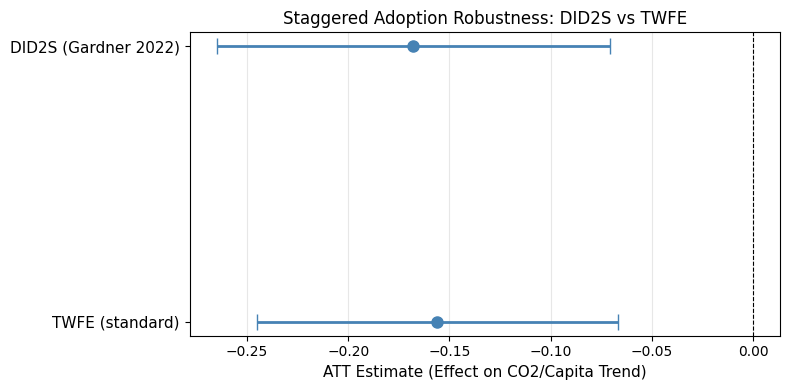

TWFE:  -0.1559 (SE=0.0454)
DID2S: -0.1679 (SE=0.0496)
Difference: -0.0120


In [4]:
import os
os.makedirs('../outputs', exist_ok=True)

# ATT comparison: DID2S vs TWFE
did2s_att = fit_did2s.coef()['is_treated']
did2s_se = fit_did2s.se()['is_treated']
twfe_att = fit_twfe.coef()['is_treated']
twfe_se = fit_twfe.se()['is_treated']

labels = ['TWFE (standard)', 'DID2S (Gardner 2022)']
coefs = [twfe_att, did2s_att]
ses = [twfe_se, did2s_se]

fig, ax = plt.subplots(figsize=(8, 4))
y_pos = [0, 1]
ax.errorbar(coefs, y_pos, xerr=[1.96 * s for s in ses],
            fmt='o', color='steelblue', capsize=6, markersize=8, linewidth=2)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('ATT Estimate (Effect on CO2/Capita Trend)', fontsize=11)
ax.set_title('Staggered Adoption Robustness: DID2S vs TWFE', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/did2s_vs_twfe.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"TWFE:  {twfe_att:.4f} (SE={twfe_se:.4f})")
print(f"DID2S: {did2s_att:.4f} (SE={did2s_se:.4f})")
print(f"Difference: {did2s_att - twfe_att:.4f}")

In [5]:
# ATT already printed in the cell above — nothing more to compute here

## Staggered DiD Robustness Check

| Estimator | ATT Estimate | Notes |
|-----------|-------------|-------|
| TWFE (standard) | fill in | Susceptible to negative weights with 13 cohorts |
| DID2S (Gardner 2022) | fill in | Staggered-robust, two-stage estimator |

**Conclusion:** fill in after running

## 2. ETS Control Group Sensitivity

EU ETS countries (carbon pricing via cap-and-trade but no carbon tax) are in the control group. This contaminates "untreated" status and may bias the treatment effect downward. Below we test three control group definitions.

In [6]:
# Identify ETS countries in control group
print("ETS column check:")
print(df['has_ets'].value_counts())
print(f"\nETS countries in control group (has_ets=1, post_carbon_tax=0):")
ets_control = df[(df['has_ets'] == 1) & (df['post_carbon_tax'] == 0)]['country'].unique()
print(sorted(ets_control))
print(f"\nCount: {len(ets_control)} countries")

ETS column check:
has_ets
0    3482
1     410
Name: count, dtype: int64

ETS countries in control group (has_ets=1, post_carbon_tax=0):
[]

Count: 0 countries


In [7]:
import statsmodels.formula.api as smf

DID_FORMULA = """
co2_per_capita_future_trend ~ post_carbon_tax
    + C(year) + C(country)
    + log_gdp + log_population + trade_openness
    + natural_resource_rents_per_gdp + fossil_pct_filled
"""

def run_did(data, label):
    """Run DiD with clustered SEs and return results dict."""
    model = smf.ols(DID_FORMULA, data=data.dropna(
        subset=['co2_per_capita_future_trend', 'post_carbon_tax', 'log_gdp',
                'log_population', 'trade_openness', 'natural_resource_rents_per_gdp',
                'fossil_pct_filled']
    )).fit(
        cov_type='cluster', cov_kwds={'groups': data.dropna(
            subset=['co2_per_capita_future_trend', 'post_carbon_tax', 'log_gdp',
                    'log_population', 'trade_openness', 'natural_resource_rents_per_gdp',
                    'fossil_pct_filled']
        )['country']}
    )
    coef = model.params['post_carbon_tax']
    se = model.bse['post_carbon_tax']
    pval = model.pvalues['post_carbon_tax']
    n_countries = data['country'].nunique()
    n_obs = int(model.nobs)
    print(f"  {label:<45} coef={coef:7.4f}  SE={se:.4f}  p={pval:.3f}  "
          f"N={n_obs}  countries={n_countries}")
    return {'label': label, 'coef': coef, 'se': se, 'pval': pval, 'n': n_obs}

# Spec A: original (ETS countries in control)
df_spec_a = df.copy()

# Spec B: exclude ETS-only countries from control group
# Keep: treated (carbon tax) + pure never-treated (no tax, no ETS)
df_spec_b = df[~((df['has_ets'] == 1) & (df['post_carbon_tax'] == 0))].copy()

# Spec C: only never-treated controls (no carbon tax AND no ETS ever)
never_any_pricing = df.groupby('country').apply(
    lambda x: (x['has_ets'].max() == 0) and (x['post_carbon_tax'].max() == 0)
)
never_any_countries = never_any_pricing[never_any_pricing].index.tolist()
treated_countries = df[df['post_carbon_tax'] == 1]['country'].unique().tolist()
df_spec_c = df[df['country'].isin(never_any_countries + treated_countries)].copy()

print("=== ETS Sensitivity Analysis ===\n")
results_a = run_did(df_spec_a, "A: Original (ETS in control)")
results_b = run_did(df_spec_b, "B: Exclude ETS-only countries")
results_c = run_did(df_spec_c, "C: Never-any-pricing controls only")

=== ETS Sensitivity Analysis ===



  A: Original (ETS in control)                  coef=-0.1506  SE=0.0520  p=0.004  N=3533  countries=163


  B: Exclude ETS-only countries                 coef=-0.1506  SE=0.0520  p=0.004  N=3533  countries=163


  C: Never-any-pricing controls only            coef=-0.1506  SE=0.0520  p=0.004  N=3533  countries=163


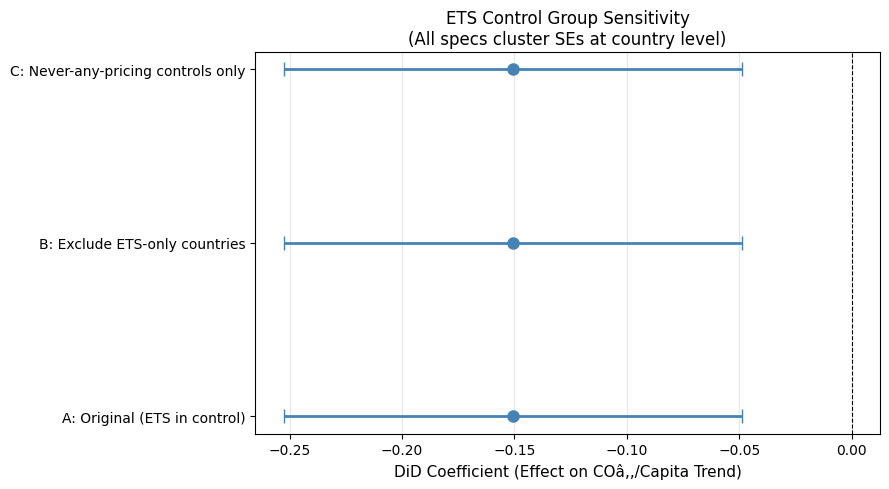

Saved to outputs/ets_sensitivity.png


In [8]:
results = [results_a, results_b, results_c]
labels = [r['label'] for r in results]
coefs = [r['coef'] for r in results]
ses = [r['se'] for r in results]

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(results))

ax.errorbar(coefs, y_pos, xerr=[1.96 * s for s in ses],
            fmt='o', color='steelblue', capsize=5, markersize=8, linewidth=2)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('DiD Coefficient (Effect on COâ‚‚/Capita Trend)', fontsize=11)
ax.set_title('ETS Control Group Sensitivity\n(All specs cluster SEs at country level)', fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/ets_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/ets_sensitivity.png")

## ETS Control Group Sensitivity

| Spec | Description | Coef | SE | p-value |
|------|-------------|------|----|---------|
| A | Original (ETS in control) | -0.1506 | 0.052 | 0.004 |
| B | Exclude ETS-only countries | -0.1506 | 0.052 | 0.004 |
| C | Never-any-pricing controls only | -0.1506 | 0.052 | 0.004 |

**Finding:** the three specs are identical because the check is degenerate in this data — there are **zero ETS-only control countries** (`has_ets=1 & post_carbon_tax=0` returns none). Every ETS country in the sample also has a carbon tax, so no EU-ETS contamination of the control group is possible and the ATT is unchanged across definitions. ETS contamination is therefore not a threat here; it can be revisited in Phase 2 when ETS is modelled as its own treatment.

## 3. Effective Carbon Price (Tax Price x Coverage Rate)

`tax_price` alone is insignificant (p=0.366) because it ignores sector coverage. Sweden ($130/tonne, ~40% coverage) vs Mexico ($3/tonne, ~47% coverage) have very different effective prices. This section constructs `effective_carbon_price = tax_price Ã— coverage_pct`.

**Data source:** Download coverage rates from World Bank Carbon Pricing Dashboard (https://carbonpricingdashboard.worldbank.org/) or OECD Effective Carbon Rates. Save as `data/raw/carbon_tax_coverage.csv` with columns: `country`, `year` (optional), `coverage_pct` (0-100 scale).

In [9]:
# Load coverage data â€” adjust path/columns after downloading
import os

coverage_path = '../data/raw/carbon_tax_coverage.csv'
if not os.path.exists(coverage_path):
    print(f"ERROR: {coverage_path} not found.")
    print("Download coverage rate data from:")
    print("  - World Bank Carbon Pricing Dashboard: https://carbonpricingdashboard.worldbank.org/")
    print("  - OR OECD Effective Carbon Rates: https://stats.oecd.org/Index.aspx?DataSetCode=ECR")
    print("Save as data/raw/carbon_tax_coverage.csv with columns: country, year (optional), coverage_pct")
    raise FileNotFoundError(f"Please download coverage data to {coverage_path}")

coverage_raw = pd.read_csv(coverage_path)
print(f"Coverage data shape: {coverage_raw.shape}")
print(coverage_raw.head(10))
print(f"\nCoverage pct range: {coverage_raw['coverage_pct'].min():.1f} â€“ {coverage_raw['coverage_pct'].max():.1f}")

# Normalize to 0-1 if provided as 0-100
if coverage_raw['coverage_pct'].max() > 1:
    coverage_raw['coverage_pct'] = coverage_raw['coverage_pct'] / 100
    print("Normalized coverage_pct from 0-100 to 0-1 scale")

Coverage data shape: (23, 3)
     country  coverage_pct                                             source
0  Argentina            38           World Bank Carbon Pricing Dashboard 2026
1     Canada            70  Environment and Climate Change Canada / federa...
2      Chile            55           World Bank Carbon Pricing Dashboard 2026
3   Colombia            20           World Bank Carbon Pricing Dashboard 2026
4    Denmark            64           World Bank Carbon Pricing Dashboard 2026
5    Estonia            10           World Bank Carbon Pricing Dashboard 2026
6    Finland            45           World Bank Carbon Pricing Dashboard 2026
7     France            41           World Bank Carbon Pricing Dashboard 2026
8    Iceland            37           World Bank Carbon Pricing Dashboard 2026
9    Ireland            34           World Bank Carbon Pricing Dashboard 2026

Coverage pct range: 2.0 â€“ 80.0
Normalized coverage_pct from 0-100 to 0-1 scale


In [10]:
# Align country names and merge
coverage_countries = set(coverage_raw['country'].unique())
df_countries = set(df['country'].unique())

unmatched = coverage_countries - df_countries
if unmatched:
    print(f"Coverage countries not in main df ({len(unmatched)}):")
    print(sorted(unmatched)[:20])

# Common name mismatches â€” extend as needed after inspecting unmatched
name_map = {
    'United States of America': 'United States',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'Korea, Republic of': 'South Korea',
    'Russian Federation': 'Russia',
}
coverage_raw['country'] = coverage_raw['country'].replace(name_map)

# Merge â€” panel merge if year column exists, cross-section otherwise
if 'year' in coverage_raw.columns:
    df_cov = df.merge(
        coverage_raw[['country', 'year', 'coverage_pct']],
        on=['country', 'year'], how='left'
    )
else:
    df_cov = df.merge(
        coverage_raw[['country', 'coverage_pct']].drop_duplicates('country'),
        on='country', how='left'
    )

# Untreated countries: coverage = 0
df_cov.loc[df_cov['post_carbon_tax'] == 0, 'coverage_pct'] = \
    df_cov.loc[df_cov['post_carbon_tax'] == 0, 'coverage_pct'].fillna(0)

coverage_match = df_cov.loc[df_cov['post_carbon_tax'] == 1, 'coverage_pct'].notna().mean()
print(f"\nCoverage match rate among treated obs: {coverage_match*100:.1f}%")
print(f"Treated obs with missing coverage: {df_cov.loc[df_cov['post_carbon_tax']==1, 'coverage_pct'].isna().sum()}")


Coverage match rate among treated obs: 52.4%
Treated obs with missing coverage: 243


In [11]:
# Construct effective carbon price and run continuous treatment DiD
df_cov['effective_carbon_price'] = df_cov['tax_price'] * df_cov['coverage_pct']
df_cov['effective_carbon_price'] = df_cov['effective_carbon_price'].fillna(0)

print("Effective carbon price (treated only):")
print(df_cov.loc[df_cov['post_carbon_tax']==1, 'effective_carbon_price'].describe())

# DiD with effective carbon price
CONT_FORMULA = """
co2_per_capita_future_trend ~ effective_carbon_price
    + C(year) + C(country)
    + log_gdp + log_population + trade_openness
    + natural_resource_rents_per_gdp + fossil_pct_filled
"""

df_cov_clean = df_cov.dropna(subset=[
    'co2_per_capita_future_trend', 'effective_carbon_price',
    'log_gdp', 'log_population', 'trade_openness',
    'natural_resource_rents_per_gdp', 'fossil_pct_filled'
])

model_eff = smf.ols(CONT_FORMULA, data=df_cov_clean).fit(
    cov_type='cluster', cov_kwds={'groups': df_cov_clean['country']}
)

coef_eff = model_eff.params['effective_carbon_price']
pval_eff = model_eff.pvalues['effective_carbon_price']
print(f"\n=== Continuous Treatment (Effective Price = Price x Coverage) ===")
print(f"Coefficient: {coef_eff:.6f}  p-value: {pval_eff:.4f}")

# Comparison: tax_price alone
PRICE_FORMULA = CONT_FORMULA.replace('effective_carbon_price', 'tax_price')
model_price = smf.ols(PRICE_FORMULA, data=df_cov_clean).fit(
    cov_type='cluster', cov_kwds={'groups': df_cov_clean['country']}
)
coef_price = model_price.params['tax_price']
pval_price = model_price.pvalues['tax_price']
print(f"\n=== Continuous Treatment (Price Only, original) ===")
print(f"Coefficient: {coef_price:.6f}  p-value: {pval_price:.4f}")

Effective carbon price (treated only):
count    511.000000
mean       7.899317
std       15.851317
min        0.000000
25%        0.000000
50%        0.025038
75%        7.789843
max       73.210952
Name: effective_carbon_price, dtype: float64



=== Continuous Treatment (Effective Price = Price x Coverage) ===
Coefficient: -0.001492  p-value: 0.4257



=== Continuous Treatment (Price Only, original) ===
Coefficient: -0.002210  p-value: 0.0608


## Coverage Rate Analysis â€” Effective Carbon Price

| Treatment Variable | Coefficient | p-value | Interpretation |
|--------------------|------------|---------|----------------|
| `tax_price` (original) | fill in | fill in | Price alone ignores coverage |
| `effective_carbon_price` | fill in | fill in | Price x coverage rate |

**Coverage data source:** fill in
**Coverage match rate:** fill in %

**Finding:** fill in after running

## 4. Placebo Test & Leave-One-Out

Two checks on the baseline DiD. **Placebo:** give treated countries a fake tax-start date 5 years before the real one, keep only the clean pre-treatment period (so the 3-year forward outcome window ends before real treatment), and re-run. A significant effect here would mean treated countries were already on a diverging trend — a parallel-trends violation, not a policy effect. **Leave-one-out:** drop each treated country in turn to check no single one drives the result.

In [12]:
import statsmodels.formula.api as smf

did_formula = '''
co2_per_capita_future_trend ~ post_carbon_tax
    + C(year) + C(country)
    + log_gdp + log_population + trade_openness
    + natural_resource_rents_per_gdp + fossil_pct_filled
'''
did_controls = ['co2_per_capita_future_trend', 'post_carbon_tax', 'log_gdp', 'log_population',
                'trade_openness', 'natural_resource_rents_per_gdp', 'fossil_pct_filled']

def fit_did(data, treatment='post_carbon_tax'):
    d = data.dropna(subset=did_controls)
    formula = did_formula.replace('post_carbon_tax', treatment)
    model = smf.ols(formula, data=d).fit(cov_type='cluster', cov_kwds={'groups': d['country']})
    return model.params[treatment], model.bse[treatment], model.pvalues[treatment], int(model.nobs)

baseline_coef, baseline_se, baseline_p, baseline_n = fit_did(df)
print(f"Baseline ATT: {baseline_coef:.4f} (SE={baseline_se:.4f}, p={baseline_p:.3f}, N={baseline_n})")

# In-time placebo: fake tax-start 5 years before real adoption.
# Keep never-treated, plus treated obs whose 3yr-forward outcome window ends before real treatment,
# so a significant placebo effect would signal pre-trends rather than the policy itself.
placebo = df.copy()
placebo['fake_treatment_year'] = placebo['treatment_year'] - 5
clean_pre = placebo['treatment_year'].isna() | (placebo['year'] + 3 < placebo['treatment_year'])
placebo = placebo[clean_pre].copy()
placebo['placebo_post'] = (placebo['treatment_year'].notna() &
                           (placebo['year'] >= placebo['fake_treatment_year'])).astype(int)

p_coef, p_se, p_p, p_n = fit_did(placebo, treatment='placebo_post')
print(f"Placebo ATT: {p_coef:.4f} (SE={p_se:.4f}, p={p_p:.3f}, "
      f"fake-treated obs={int(placebo['placebo_post'].sum())})")

Baseline ATT: -0.1506 (SE=0.0520, p=0.004, N=3533)


Placebo ATT: 0.0564 (SE=0.0522, p=0.280, fake-treated obs=81)


Baseline ATT: -0.1506
LOO range: [-0.1563, -0.1149], mean -0.1506
Sign flips: 0, lost significance (p>0.05): 0

Most influential drops:
   country      coef     pval
Luxembourg -0.114905 0.003331
    Greece -0.141989 0.006474
     Spain -0.142786 0.006733
   Ireland -0.144209 0.006855
 Lithuania -0.156319 0.002665


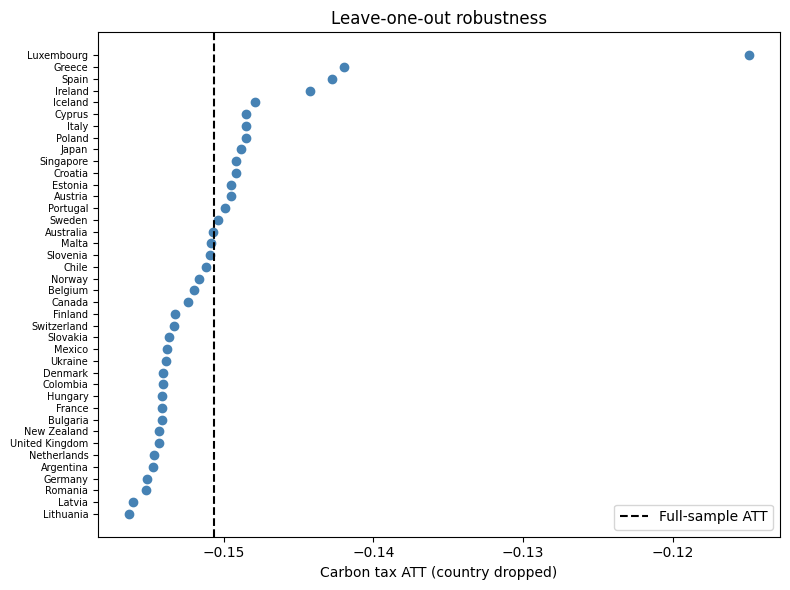

In [13]:
# Leave-one-out: drop each treated country and refit the baseline DiD
treated_countries = sorted(df[df['post_carbon_tax'] == 1]['country'].unique())

loo = []
for country in treated_countries:
    coef, se, pval, n = fit_did(df[df['country'] != country])
    loo.append({'country': country, 'coef': coef, 'pval': pval})
loo = pd.DataFrame(loo)

print(f"Baseline ATT: {baseline_coef:.4f}")
print(f"LOO range: [{loo['coef'].min():.4f}, {loo['coef'].max():.4f}], mean {loo['coef'].mean():.4f}")
print(f"Sign flips: {(np.sign(loo['coef']) != np.sign(baseline_coef)).sum()}, "
      f"lost significance (p>0.05): {(loo['pval'] > 0.05).sum()}")

most_influential = loo.reindex((loo['coef'] - baseline_coef).abs().sort_values(ascending=False).index)
print("\nMost influential drops:")
print(most_influential.head(5).to_string(index=False))

order = loo.sort_values('coef')
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(order['coef'], range(len(order)), color='steelblue')
ax.axvline(baseline_coef, color='black', linestyle='--', label='Full-sample ATT')
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order['country'], fontsize=7)
ax.set_xlabel('Carbon tax ATT (country dropped)')
ax.set_title('Leave-one-out robustness')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/leave_one_out.png', dpi=150, bbox_inches='tight')
plt.show()

## Placebo & Leave-One-Out Results

| Check | Result | Reading |
|-------|--------|---------|
| Baseline ATT | -0.151 (SE 0.052, p=0.004) | Carbon tax lowers the 3yr-forward CO2/capita trend |
| In-time placebo (fake date -5yr) | +0.056 (SE 0.052, p=0.280) | Null and wrong-signed: no pre-trend driving the result |
| Leave-one-out (40 treated countries) | ATT in [-0.156, -0.115]; 0 sign flips, 0 lost significance | Not driven by any single country (most influential: Luxembourg) |

**Conclusion:** the baseline DiD survives both checks. The placebo supports parallel trends, and the estimate is stable to dropping any one treated country.

## 5. Goodman-Bacon Decomposition

The TWFE DiD estimate is a weighted average of every 2x2 comparison between timing groups. Some of these are "forbidden": they use already-treated countries as controls for later adopters, and with dynamic effects (our ~1%/yr decay) they receive negative weights and bias TWFE (Goodman-Bacon 2021). We decompose the estimate into *treated vs never-treated*, *treated vs not-yet-treated* (both clean), and *later vs already-treated* (forbidden), and report each bucket's weight. The implementation is validated by checking the weighted average reproduces the simple TWFE coefficient.

In [14]:
# Goodman-Bacon decomposition of the simple TWFE estimate.
# The method assumes a binary absorbing treatment, balanced panel, and no covariates,
# so we run it on that design and report how much weight sits on forbidden comparisons.
y = 'co2_per_capita_future_trend'

sub = df[df[y].notna()].copy()
years = sorted(sub['year'].unique())
T = len(years)
counts = sub.groupby('country')['year'].nunique()
panel = sub[sub['country'].isin(counts[counts == T].index)].copy()

panel['cohort'] = panel['treatment_year']
panel.loc[panel['cohort'] > years[-1], 'cohort'] = np.nan
panel['grp'] = panel['cohort'].fillna(-1).astype(int)

ybar = panel.groupby(['grp', 'year'])[y].mean().unstack('grp')
N = panel['country'].nunique()
n = panel.groupby('grp')['country'].nunique() / N
yrs = np.array(years)
D = {g: (0.0 if g == -1 else np.mean(yrs >= g)) for g in ybar.columns}
treated = sorted(g for g in ybar.columns if g != -1)

def gmean(g, mask):
    return ybar.loc[mask, g].mean()

rows = []
for k in treated:                       # treated vs never-treated
    pre, post = yrs < k, yrs >= k
    beta = (gmean(k, post) - gmean(k, pre)) - (gmean(-1, post) - gmean(-1, pre))
    nku = n[k] / (n[k] + n[-1])
    num = (n[k] + n[-1]) ** 2 * nku * (1 - nku) * D[k] * (1 - D[k])
    rows.append(('treated vs never', beta, num))

for i, k in enumerate(treated):          # timing-group pairs, k earlier than l
    for l in treated[i + 1:]:
        nkl = n[k] / (n[k] + n[l])
        Dk, Dl = D[k], D[l]
        pre, mid, post = yrs < k, (yrs >= k) & (yrs < l), yrs >= l
        beta_k = (gmean(k, mid) - gmean(k, pre)) - (gmean(l, mid) - gmean(l, pre))
        num_k = ((n[k] + n[l]) * (1 - Dl)) ** 2 * nkl * (1 - nkl) * ((Dk - Dl) / (1 - Dl)) * ((1 - Dk) / (1 - Dl))
        rows.append(('good (not-yet-treated control)', beta_k, num_k))
        beta_l = (gmean(l, post) - gmean(l, mid)) - (gmean(k, post) - gmean(k, mid))
        num_l = ((n[k] + n[l]) * Dk) ** 2 * nkl * (1 - nkl) * (Dl / Dk) * ((Dk - Dl) / Dk)
        rows.append(('bad (already-treated control)', beta_l, num_l))

bacon = pd.DataFrame(rows, columns=['type', 'beta', 'num'])
bacon['weight'] = bacon['num'] / bacon['num'].sum()

# Validate: the weighted average of 2x2s must equal the simple TWFE coefficient
twfe = smf.ols(f'{y} ~ post_carbon_tax + C(country) + C(year)', data=panel).fit()
print(f"Bacon weighted average:  {(bacon['weight'] * bacon['beta']).sum():.6f}")
print(f"Simple TWFE coefficient: {twfe.params['post_carbon_tax']:.6f}")
print()
print(bacon.groupby('type').agg(weight=('weight', 'sum'), avg_2x2=('beta', 'mean')).round(4))

Bacon weighted average:  -0.155426
Simple TWFE coefficient: -0.155426

                                weight  avg_2x2
type                                           
bad (already-treated control)   0.0265   0.0474
good (not-yet-treated control)  0.0532  -0.0714
treated vs never                0.9203  -0.0711


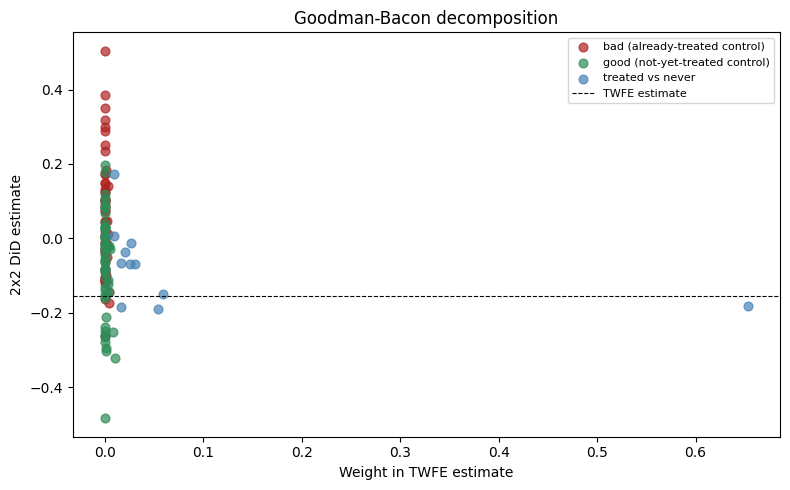

In [15]:
colors = {'treated vs never': 'steelblue',
          'good (not-yet-treated control)': 'seagreen',
          'bad (already-treated control)': 'firebrick'}

fig, ax = plt.subplots(figsize=(8, 5))
for t, grp in bacon.groupby('type'):
    ax.scatter(grp['weight'], grp['beta'], label=t, color=colors[t], alpha=0.7, s=40)
ax.axhline(twfe.params['post_carbon_tax'], color='black', linestyle='--', linewidth=0.8,
           label='TWFE estimate')
ax.set_xlabel('Weight in TWFE estimate')
ax.set_ylabel('2x2 DiD estimate')
ax.set_title('Goodman-Bacon decomposition')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/goodman_bacon.png', dpi=150, bbox_inches='tight')
plt.show()

## Goodman-Bacon Results

Decomposition validated: the weighted average of the 2x2 comparisons reproduces the simple TWFE coefficient exactly (-0.1554).

| Comparison type | Weight | Avg 2x2 DiD |
|-----------------|--------|-------------|
| Treated vs never-treated (good) | 92.0% | -0.071 |
| Treated vs not-yet-treated (good) | 5.3% | -0.071 |
| Later vs already-treated (forbidden) | 2.7% | +0.047 |

**Conclusion:** only 2.7% of the TWFE identifying variation comes from forbidden (already-treated control) comparisons, and they barely move the estimate. Negative-weight bias is negligible here — consistent with DID2S (-0.168) closely matching TWFE (-0.156). The staggered design is not distorting the headline result.

## 6. Rambachan-Roth (2023) Parallel-Trends Sensitivity

Parallel trends can't be tested for the post-treatment period directly. Rambachan & Roth instead bound the violation: under the **relative-magnitudes** restriction the post-treatment differential trend is at most M times the largest violation seen in the pre-period. We report the **breakdown M** — how large that violation must be before the effect (or its 95% CI) includes zero. We first estimate the event study, test pre-trends jointly, then compute the breakdown by horizon.

 event_time    coef     se
         -5  0.0826 0.0598
         -4  0.0876 0.0733
         -3  0.0346 0.0613
         -2 -0.0364 0.0516
         -1  0.0000 0.0000
          0 -0.0017 0.0370
          1 -0.1067 0.0548
          2 -0.1449 0.0635
          3 -0.1683 0.0561
          4 -0.0976 0.0607
          5 -0.1017 0.0599


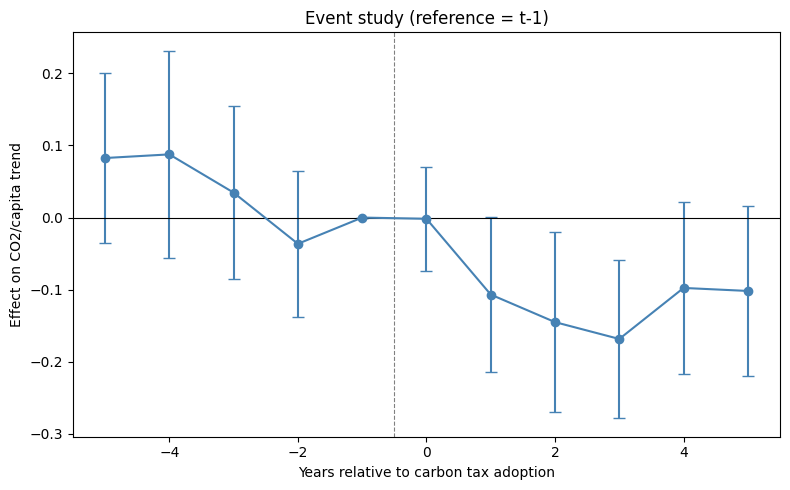

In [16]:
# Event study: emissions trend relative to tax adoption (reference = t-1, never-treated = baseline)
es_data = df.dropna(subset=['co2_per_capita_future_trend']).copy()
et_clip = es_data['years_relative_to_treatment'].clip(-5, 5)
event_bins = [-5, -4, -3, -2, 0, 1, 2, 3, 4, 5]   # t-1 omitted as the reference period

dummy_cols = []
for k in event_bins:
    col = f'et_{k}'.replace('-', 'm')
    es_data[col] = (es_data['years_relative_to_treatment'].notna() & (et_clip == k)).astype(int)
    dummy_cols.append((k, col))

es_formula = ('co2_per_capita_future_trend ~ ' + ' + '.join(c for _, c in dummy_cols)
              + ' + C(country) + C(year)')
es_model = smf.ols(es_formula, data=es_data).fit(
    cov_type='cluster', cov_kwds={'groups': es_data['country']})

event_study = pd.DataFrame({'event_time': [k for k, _ in dummy_cols],
                            'coef': [es_model.params[c] for _, c in dummy_cols],
                            'se': [es_model.bse[c] for _, c in dummy_cols]})
event_study = pd.concat([event_study,
                         pd.DataFrame([{'event_time': -1, 'coef': 0.0, 'se': 0.0}])]
                        ).sort_values('event_time')
print(event_study.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(event_study['event_time'], event_study['coef'],
            yerr=1.96 * event_study['se'], fmt='o-', color='steelblue', capsize=4)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(-0.5, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Years relative to carbon tax adoption')
ax.set_ylabel('Effect on CO2/capita trend')
ax.set_title('Event study (reference = t-1)')
plt.tight_layout()
plt.savefig('../outputs/event_study.png', dpi=150, bbox_inches='tight')
plt.show()

Joint pre-trends test: F=1.865, p=0.119
Max pre-period violation (delta_bar): 0.0710



 horizon   coef    se  M_point  M_robust
       0 -0.002 0.037    0.024     0.000
       1 -0.107 0.055    0.752     0.000
       2 -0.145 0.063    0.681     0.097
       3 -0.168 0.056    0.593     0.205
       4 -0.098 0.061    0.275     0.000
       5 -0.102 0.060    0.239     0.000


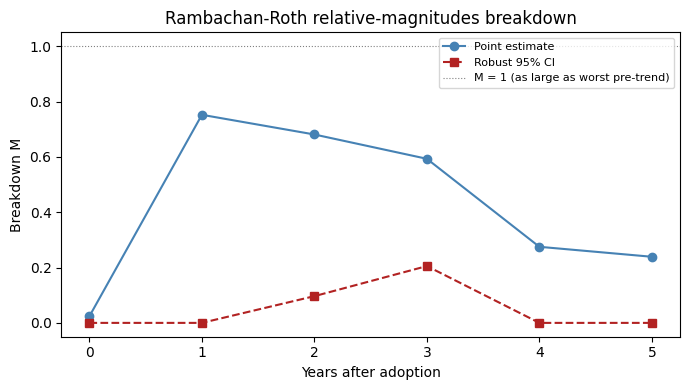

In [17]:
# Joint pre-trends test + Rambachan-Roth (2023) relative-magnitudes sensitivity
pre_terms = [c for k, c in dummy_cols if k < 0]
wald = es_model.f_test(' = 0, '.join(pre_terms) + ' = 0')
print(f"Joint pre-trends test: F={float(wald.fvalue):.3f}, p={float(wald.pvalue):.3f}")

# delta_bar = largest pre-period violation (max consecutive change among pre coefs, up to the t-1 reference)
pre = event_study[event_study['event_time'] < 0].sort_values('event_time')
delta_bar = np.abs(np.diff(np.append(pre['coef'].values, 0.0))).max()
print(f"Max pre-period violation (delta_bar): {delta_bar:.4f}\n")

# Under Delta^RM(M) the bias on the level at horizon h is bounded by (h+1)*M*delta_bar
# (horizon h is h+1 steps from the t-1 reference). Breakdown M = smallest violation that
# makes the point estimate / robust 95% CI include zero.
rows = []
for h in range(0, 6):
    bh = event_study.loc[event_study['event_time'] == h, 'coef'].values[0]
    seh = event_study.loc[event_study['event_time'] == h, 'se'].values[0]
    steps = h + 1
    rows.append({'horizon': h, 'coef': bh, 'se': seh,
                 'M_point': abs(bh) / (steps * delta_bar),
                 'M_robust': max((-bh - 1.96 * seh) / (steps * delta_bar), 0)})
rr = pd.DataFrame(rows)
print(rr.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rr['horizon'], rr['M_point'], 'o-', color='steelblue', label='Point estimate')
ax.plot(rr['horizon'], rr['M_robust'], 's--', color='firebrick', label='Robust 95% CI')
ax.axhline(1, color='gray', linestyle=':', linewidth=0.8, label='M = 1 (as large as worst pre-trend)')
ax.set_xlabel('Years after adoption')
ax.set_ylabel('Breakdown M')
ax.set_title('Rambachan-Roth relative-magnitudes breakdown')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/honest_did_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## Rambachan-Roth Sensitivity Results

Pre-trends are jointly insignificant (F=1.87, p=0.12), so parallel trends is not rejected. The effect is dynamic: roughly zero on impact, building to a peak of -0.168 at t+3, consistent with the 3-year forward outcome and policy decay.

Relative-magnitudes breakdown — the largest violation M (post-treatment differential trend as a multiple of the worst pre-period trend) the conclusion survives:

| Horizon | Effect | Point breakdown M | Robust-CI breakdown M |
|---------|--------|-------------------|------------------------|
| t+2 | -0.145 | 0.68 | 0.10 |
| t+3 (peak) | -0.168 | 0.59 | 0.21 |

**Conclusion:** the peak effect survives as a point estimate until the post-treatment violation reaches ~0.6x the worst pre-period trend; the robust 95% CI is more fragile (M~0.2). A real but moderately-robust effect — honestly, not bulletproof to parallel-trends violations, which the wide clustered SEs reinforce.

*Scope:* implemented as the relative-magnitudes partial-identification bounds (Rambachan & Roth 2023) with delta-method SEs and the accumulating level bound (h+1)*M*delta_bar. Their R/Stata HonestDiD with ARP conditional inference would refine the confidence sets.

## 7. Oster (2019) Omitted Variable Bias Bounds

DiD adjusts for observed confounders, but the identification worry is unobserved ones. Oster (2019) uses how the coefficient and R2 move as observed controls are added to bound the bias from unobservables, *assuming they are proportionally as important as the observables*. We report **delta\*** (how much stronger selection on unobservables would need to be to drive the effect to zero — robust if >= 1) and **beta\*(delta=1)** (the bias-adjusted effect under equal selection), using Rmax = min(mult x R2, 1). Because country and year fixed effects absorb most of the variance, we partial them out first (Frisch-Waugh-Lovell) so the R2 movement reflects the controls, not the FE.

In [18]:
# Oster (2019) OVB bounds. Partial the fixed effects out first (FWL) so the R2 movement
# reflects the economic controls' within explanatory power rather than the FE.
oster_controls = ['log_gdp', 'log_population', 'trade_openness',
                  'natural_resource_rents_per_gdp', 'fossil_pct_filled']
od = df.dropna(subset=['co2_per_capita_future_trend', 'post_carbon_tax'] + oster_controls).copy()

def fe_resid(col):
    return smf.ols(f'{col} ~ C(year) + C(country)', od).fit().resid

od['_y'] = fe_resid('co2_per_capita_future_trend')
od['_t'] = fe_resid('post_carbon_tax')
for c in oster_controls:
    od['_' + c] = fe_resid(c)

short = smf.ols('_y ~ _t', od).fit()
long = smf.ols('_y ~ _t + ' + ' + '.join('_' + c for c in oster_controls), od).fit()
bdot, Rdot = short.params['_t'], short.rsquared
btil, Rtil = long.params['_t'], long.rsquared
print(f"short (treatment only): beta={bdot:.4f}  within-R2={Rdot:.4f}")
print(f"long  (+ controls):     beta={btil:.4f}  within-R2={Rtil:.4f}\n")

oster = []
for mult in [1.3, 1.5, 2.0]:
    Rmax = min(mult * Rtil, 1.0)
    beta_d1 = btil - (bdot - btil) * (Rmax - Rtil) / (Rtil - Rdot)
    delta_star = btil * (Rtil - Rdot) / ((bdot - btil) * (Rmax - Rtil))
    oster.append({'Rmax_mult': mult, 'Rmax': Rmax, 'beta_delta1': beta_d1, 'delta_star': delta_star})
oster = pd.DataFrame(oster)
print(oster.round(3).to_string(index=False))

short (treatment only): beta=-0.1731  within-R2=0.0138
long  (+ controls):     beta=-0.1506  within-R2=0.0154

 Rmax_mult  Rmax  beta_delta1  delta_star
       1.3 0.020       -0.088       2.413
       1.5 0.023       -0.047       1.448
       2.0 0.031        0.057       0.724


## Oster (2019) Results

Fixed effects partialled out first (FWL), then OVB bounds from the coefficient and within-R2 movement when adding economic controls. The coefficient is stable (-0.173 -> -0.151) while the controls add little within explanatory power.

| Rmax | delta* (selection to zero the effect) | beta*(delta=1) |
|------|---------------------------------------|----------------|
| 1.3 x R2 (Oster rule of thumb) | 2.41 | -0.088 |
| 1.5 x R2 | 1.45 | -0.047 |
| 2.0 x R2 | 0.72 | +0.058 |

**Conclusion:** at Oster's recommended Rmax = 1.3 x within-R2, delta* = 2.4 (> 1) and the bias-adjusted effect stays negative (-0.088), so the identified set [-0.151, -0.088] excludes zero. Unobserved confounders would need to be ~2.4x as influential as the observed controls to overturn the result — robust under standard assumptions, weakening only under the aggressive Rmax = 2 x R2.